# Train with MLflow tracking

Goal:

- Train a YOLO model to detect license plates.
- Track parameters, metrics and artifacts in the SageMaker MLflow tracking server.
- Export the trained model to `s3://<bucket>/trains/models/`.


## Environment

Install libraries.


In [1]:
%pip install -q -U ultralytics torch torchvision onnx onnxslim mlflow sagemaker-mlflow

Note: you may need to restart the kernel to use updated packages.


Inspect environment.


In [2]:
%matplotlib inline

import os
import sys
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import torch
import torchvision
import ultralytics

from sagemaker.core.helper.session_helper import Session

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# define local paths
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RUNS = ROOT / "runs"
MODELS = ROOT / "models"

for d in (RAW, PROCESSED, RUNS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

REGION = Session().boto_region_name

# get bucket
env_file = Path.home() / ".sagemaker-yolo.env"
if "BUCKET" not in os.environ and env_file.exists():
    for line in env_file.read_text().splitlines():
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip())

BUCKET = os.environ["BUCKET"]

# bucket keys
S3_RAW = f"s3://{BUCKET}/data/raw"
S3_SPLIT = f"s3://{BUCKET}/data/split"
S3_MODELS = f"s3://{BUCKET}/trains/models"

# device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# print environment
print("python         ", sys.version.split()[0])
print("torch          ", torch.__version__)
print("torchvision    ", torchvision.__version__)
print("ultralytics    ", ultralytics.__version__)
print("mlflow         ", mlflow.__version__)
print("sagemaker-mlflow", version("sagemaker-mlflow"))
print("cuda           ", torch.cuda.is_available())
print("device         ", DEVICE)
print("region         ", REGION)
print("bucket         ", BUCKET)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


python          3.12.13
torch           2.13.0+cu130
torchvision     0.28.0+cu130
ultralytics     8.4.118
mlflow          3.15.1
sagemaker-mlflow 0.5.0
cuda            False
device          cpu
region          ca-central-1
bucket          sagemaker-yolo-dev-0luf20


## Configure MLflow server


In [3]:
import boto3

from src.tracking import tracking_uri

# set tracking server
TRACKING_URI = tracking_uri()
mlflow.set_tracking_uri(TRACKING_URI)

# create experiment
EXPERIMENT = "yolo-plate-detection"
experiment = mlflow.set_experiment(EXPERIMENT)

# get tracking server
server = boto3.client("sagemaker").describe_mlflow_tracking_server(
    TrackingServerName=TRACKING_URI.rsplit("/", 1)[-1]
)
# get tracking server url
UI_URL = server["TrackingServerUrl"]

# print mlflow server
print("tracking  ", TRACKING_URI)
print("status    ", server["TrackingServerStatus"])
print("experiment", EXPERIMENT, f"(id {experiment.experiment_id})")

# list experiments to confirm connection
print("\nexisting experiments")
for exp in mlflow.search_experiments():
    print(f"  {exp.experiment_id:>4}  {exp.name}")

# print link and experiments
print(f"\nUI: {UI_URL}/#/experiments/{experiment.experiment_id}")

tracking   arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev
status     Created
experiment yolo-plate-detection (id 1)

existing experiments
     3  yolo-plate-detection-cpu-vs-gpu
     2  yolo-plate-detection-sweep
     1  yolo-plate-detection
     0  Default

UI: https://t-p1ukzmxk6vss.ca-central-1.experiments.sagemaker.aws/#/experiments/1


## Data processing

Pull the raw data from S3, split it, push the split back.


In [4]:
from src.data_loader import build_split, summarize, verify_split, write_data_yaml
from src.s3_sync import download, upload

# e.g. 100 for a fast smoke run
# LIMIT = 100
LIMIT = None  # all images

SPLIT_SEED = 0  # split random seed

# download data
print(download(S3_RAW, RAW))

# inspect and print summary
stats = summarize(RAW)
print({k: stats[k] for k in ("pairs", "boxes_total", "boxes_per_image_max", "malformed")})

# split
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=SPLIT_SEED))
print(verify_split(PROCESSED))

# save split in s3
print(upload(PROCESSED, S3_SPLIT, delete=True))

# create data config yaml file
names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)
print(data_yaml.read_text())

{'downloaded': 0, 'skipped': 1113}
{'pairs': 556, 'boxes_total': 574, 'boxes_per_image_max': 3, 'malformed': []}


{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


{'uploaded': 295, 'skipped': 817, 'removed': 16}
path: /home/sagemaker-user/sagemaker-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Train with tracking

Track by built-in MLflow callback, logging hyperparameters, per-epoch metrics and the run artifacts on its own.

- `MLFLOW_KEEP_RUN_ACTIVE` holds the run open after training.


In [5]:
import time

from ultralytics import YOLO

from src.data_loader import build_train_cfg

# create train parameters
train_cfg = build_train_cfg(
    device=DEVICE,
    workers=(os.cpu_count() or 2) if DEVICE != "cpu" else 0,
)
train_cfg["project"] = str(ROOT / train_cfg["project"])

cfg = {k: v for k, v in train_cfg.items() if k != "model"}
n_train = len(list((PROCESSED / "train" / "images").iterdir()))

# get ultralytics MLflow callback from env var
os.environ["MLFLOW_EXPERIMENT_NAME"] = EXPERIMENT
os.environ["MLFLOW_RUN"] = f"{DEVICE}-{n_train}img-{cfg['imgsz']}px-{cfg['epochs']}ep"
os.environ["MLFLOW_KEEP_RUN_ACTIVE"] = "true"

print(f"experiment {EXPERIMENT}")
print(f"run        {os.environ['MLFLOW_RUN']}")

# construct yolo model
model = YOLO(train_cfg["model"])

start = time.time()
# train the model
results = model.train(data=str(data_yaml), **cfg)
elapsed = time.time() - start

print(f"\nelapsed: {elapsed:.0f}s ({elapsed / 60:.1f} min)")

experiment yolo-plate-detection
run        cpu-445img-640px-10ep


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sagemaker-train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

Speed: 0.9ms preprocess, 67.8ms inference, 0.0ms loss, 2.3ms postprocess per image


Results saved to /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train


MLflow: results logged to arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev
MLflow: disable with 'yolo settings mlflow=False'


MLflow: mlflow run still alive, remember to close it using mlflow.end_run()



elapsed: 1618s (27.0 min)


### Log dataset context

log hyperparameters and metrics with mlflow.


In [6]:
from src.tracking import log_dataset_context

# save dir
save_dir = Path(results.save_dir)

# log with mlflow
logged = log_dataset_context(
    PROCESSED,
    RAW,
    **{"data.limit": str(LIMIT), "data.seed": SPLIT_SEED, "run.device": str(DEVICE)},
)
mlflow.log_metric("elapsed_seconds", elapsed)

# get run id
run_id = mlflow.active_run().info.run_id
print(f"run_id {run_id}")
for key, value in logged.items():
    print(f"  {key:26} {value}")

# terminate run
mlflow.end_run()
print("\nrun closed")

run_id 303d668df5c54b5297ab40419fa2cadd
  data.train_images          445
  data.train_boxes           458
  data.val_images            111
  data.val_boxes             116
  data.total_images          556
  data.available_images      556
  data.fraction_used         1.0
  data.limit                 None
  data.seed                  0
  run.device                 cpu
🏃 View run cpu-445img-640px-10ep at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/1/runs/303d668df5c54b5297ab40419fa2cadd
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/1



run closed


Confirm by read run from mlflow.


In [7]:
# get run
fetched = mlflow.get_run(run_id)

print(f"run_id  {run_id}")
print(f"status  {fetched.info.status}")

# print metrics
print("\nfinal metrics")
for key in sorted(fetched.data.metrics):
    if any(m in key for m in ("mAP", "precision", "recall")):
        print(f"  {key:28} {fetched.data.metrics[key]:.4f}")

# print dataset params
print("\ndataset params")
for key in sorted(k for k in fetched.data.params if k.startswith("data.")):
    print(f"  {key:28} {fetched.data.params[key]}")

# print Artifacts
print("\nartifacts")
for artifact in mlflow.artifacts.list_artifacts(run_id=run_id):
    print(f"  {artifact.path}")

run_id  303d668df5c54b5297ab40419fa2cadd
status  FINISHED

final metrics
  metrics/mAP50-95B            0.7786
  metrics/mAP50B               0.9851
  metrics/precisionB           0.9658
  metrics/recallB              0.9735

dataset params
  data.available_images        556
  data.fraction_used           1.0
  data.limit                   None
  data.seed                    0
  data.total_images            556
  data.train_boxes             458
  data.train_images            445
  data.val_boxes               116
  data.val_images              111

artifacts


  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  args.yaml
  confusion_matrix.png
  confusion_matrix_normalized.png
  labels.jpg
  results.csv
  results.png
  train_batch0.jpg
  train_batch1.jpg
  train_batch2.jpg
  val_batch0_labels.jpg
  val_batch0_pred.jpg
  val_batch1_labels.jpg
  val_batch1_pred.jpg
  val_batch2_labels.jpg
  val_batch2_pred.jpg
  weights


Plot history.


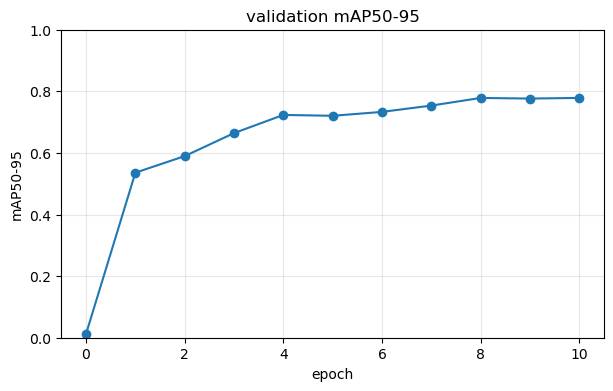

 epoch   mAP50-95
     0     0.0125
     1     0.5359
     2     0.5897
     3     0.6643
     4     0.7234
     5     0.7206
     6     0.7332
     7     0.7537
     8     0.7785
     9     0.7765
    10     0.7786


In [13]:
client = mlflow.tracking.MlflowClient()

# mlflow does not guarantee ordering, sort by step before plotting
history = sorted(client.get_metric_history(run_id, "metrics/mAP50-95B"), key=lambda p: p.step)

plt.figure(figsize=(7, 4))
plt.plot([p.step for p in history], [p.value for p in history], marker="o")
plt.xlabel("epoch")
plt.ylabel("mAP50-95")
plt.title("validation mAP50-95")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

print(f"{'epoch':>6} {'mAP50-95':>10}")
for point in history:
    print(f"{point.step:>6} {point.value:>10.4f}")

## List runs

Compare every run in the experiment, side by side.


In [9]:
from src.tracking import compare_runs

compare_runs(EXPERIMENT)

,mlflow.runName,epochs,imgsz,data.train_images,metrics/mAP50B,metrics/mAP50-95B,metrics/precisionB,metrics/recallB
0,cpu-445img-640px-10ep,10,640,445,0.985073,0.778561,0.965789,0.973478
1,cpu-8img-640px-10ep,10,640,8,0.023596,0.009573,0.003333,1.000000
2,cpu-8img-640px-10ep,10,640,8,0.023596,0.009573,0.003333,1.000000
3,cpu-8img-640px-10ep,10,640,8,0.023596,0.009573,0.003333,1.000000
4,cpu-445img-640px-10ep,10,640,445,0.985073,0.778561,0.965789,0.973478
5,cpu-80img-640px-10ep,10,640,None,NaN,NaN,NaN,NaN
6,cpu-80img-10ep-640px,10,640,80,0.478018,0.364934,1.000000,0.342226
7,dapper-hawk-604,None,None,80,NaN,NaN,NaN,NaN
8,cpu-80img-10ep-640px,10,640,80,0.478018,0.364934,1.000000,0.342226


Open the MLflow UI from the Studio launcher.

Note the UI lands on the `Default` experiment, which is empty — switch to
`yolo-plate-detection` in the sidebar, or use the direct link printed above.


## Export model

Export `best.pt` to ONNX and upload it to S3.


In [10]:
import shutil

# construct model freom best weights
best = YOLO(str(save_dir / "weights" / "best.pt"))

# export model
exported = Path(best.export(format="onnx", imgsz=train_cfg["imgsz"], opset=12, simplify=True))

# count image
n_images = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train", "val"))

# model file name
onnx_path = MODELS / (
    f"{train_cfg['name']}-{DEVICE}-{n_images}img-{train_cfg['imgsz']}px-{train_cfg['epochs']}ep.onnx"
)
shutil.move(str(exported), onnx_path)

print(onnx_path.name)
print(f"{onnx_path.stat().st_size / 1e6:.1f} MB")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs



PyTorch: starting from '/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)



ONNX: starting export with onnx 1.22.0 opset 12...


ONNX: slimming with onnxslim 0.1.95...


2026-08-12 02:54:02.031059001 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 1.4s, saved as '/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx' (10.1 MB)



Export complete (1.8s)
Results saved to /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx
Predict:         yolo predict task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx imgsz=640 data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml  
Visualize:       https://netron.app


sagemaker-train-cpu-556img-640px-10ep.onnx
10.6 MB


Write a metadata file.


In [11]:
import json
from datetime import datetime, timezone

sidecar = onnx_path.with_suffix(".metadata.json")
sidecar.write_text(json.dumps({
    "imgsz": train_cfg["imgsz"],
    "names": [best.names[i] for i in sorted(best.names)],
    "mlflow": {
        "run_id": run_id,
        "experiment": EXPERIMENT,
        "tracking_uri": TRACKING_URI,
    },
    "train": {k: train_cfg[k] for k in ("model", "epochs", "batch", "seed")},
    "images": n_images,
    "exported_at": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(sidecar.read_text())

{
  "imgsz": 640,
  "names": [
    "car_plate"
  ],
  "mlflow": {
    "run_id": "303d668df5c54b5297ab40419fa2cadd",
    "experiment": "yolo-plate-detection",
    "tracking_uri": "arn:aws:sagemaker:ca-central-1:099139718958:mlflow-tracking-server/sagemaker-yolo-dev"
  },
  "train": {
    "model": "yolo11n.pt",
    "epochs": 10,
    "batch": 8,
    "seed": 0
  },
  "images": 556,
  "exported_at": "2026-08-12T02:54:02.632296+00:00"
}


Upload to S3 and attach the same files to the MLflow run.


In [12]:
from src.s3_sync import list_objects, upload_files

dest = f"{S3_MODELS}/{onnx_path.stem}"
weights = save_dir / "weights" / "best.pt"

# upload model file
for uri in upload_files([onnx_path, sidecar, weights], dest):
    print(uri)

# save export uri to mlflow
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(str(onnx_path), artifact_path="export")
    mlflow.log_artifact(str(sidecar), artifact_path="export")
    mlflow.set_tag("export.s3_uri", dest)

print()
for key, meta in sorted(list_objects(dest).items()):
    print(f"  {meta['size'] / 1e6:>6.1f} MB  {key.rsplit('/', 1)[-1]}")

print(f"\nrun: {UI_URL}/#/experiments/{experiment.experiment_id}/runs/{run_id}")

s3://sagemaker-yolo-dev-0luf20/trains/models/sagemaker-train-cpu-556img-640px-10ep/sagemaker-train-cpu-556img-640px-10ep.onnx
s3://sagemaker-yolo-dev-0luf20/trains/models/sagemaker-train-cpu-556img-640px-10ep/sagemaker-train-cpu-556img-640px-10ep.metadata.json
s3://sagemaker-yolo-dev-0luf20/trains/models/sagemaker-train-cpu-556img-640px-10ep/best.pt


🏃 View run cpu-445img-640px-10ep at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/1/runs/303d668df5c54b5297ab40419fa2cadd
🧪 View experiment at: https://ca-central-1.experiments.sagemaker.aws/#/experiments/1



     5.5 MB  best.pt
     0.0 MB  sagemaker-train-cpu-556img-640px-10ep.metadata.json
    10.6 MB  sagemaker-train-cpu-556img-640px-10ep.onnx

run: https://t-p1ukzmxk6vss.ca-central-1.experiments.sagemaker.aws/#/experiments/1/runs/303d668df5c54b5297ab40419fa2cadd
